# Daily Activity Exploration — FIFA World Cup 2026

**Goal:** understand whether daily activity around Toronto and Vancouver venues is elevated during FIFA World Cup match days/month in June 2026, relative to three benchmark comparisons:

1. **June 2026 vs. June 2025** — same calendar month, one year apart (controls for seasonality).
2. **June 2026 vs. May 2026** — the month immediately preceding (controls for any 2026-specific trend, but not seasonality).
3. **Match days vs. non-match days within June 2026** — the most direct test, since it isolates the effect of an actual game happening that day from general "tournament month" effects.

Data lives in `data/match-activity/daily_final_v2.csv` — one row per `DATE` x `GEOMETRYLEVEL`, with:
- `UNIQUESTOPS_NUM` — the raw activity count (what we called `UNIQUESTOPS` before).
- `UNIQUESTOPS_DENOM` — the total device panel size that day (the pool `UNIQUESTOPS_NUM` was drawn from).
- `normed_devices` — `UNIQUESTOPS_NUM / UNIQUESTOPS_DENOM`, i.e. activity **normalized for the size of the underlying device panel** that day. This matters because the raw count can drift just because more/fewer devices were observed overall that day, independent of any real change in foot traffic — `normed_devices` strips that out.

We'll run every comparison on **both** the raw count and the normalized rate, since a real World-Cup effect should show up in both, while a panel-size artifact would only show up in the raw count.

`GEOMETRYLEVEL` encodes both **city** (`toronto` / `vancouver`) and **spatial resolution** (`csd`, or a `merged_*` buffer ring at 100m–10km around the stadium). We'll split that out into two columns so we can facet by each independently.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from tqdm.notebook import tqdm

pd.options.display.float_format = "{:,.0f}".format
plt.rcParams["figure.dpi"] = 110

/home/aniket/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
DATA_PATH = "../../data/match-activity/daily_final_v2.csv"

# Benchmark windows
JUNE_2025 = ("2025-06-01", "2025-06-30")
MAY_2026 = ("2026-05-01", "2026-05-31")
JUNE_2026 = ("2026-06-01", "2026-06-30")

# FIFA World Cup 2026 match days per host city (all dates in June 2026)
MATCH_DAYS = {
    "toronto": pd.to_datetime(["2026-06-12", "2026-06-17", "2026-06-20", "2026-06-23", "2026-06-26"]),
    "vancouver": pd.to_datetime(["2026-06-13", "2026-06-18", "2026-06-21", "2026-06-24", "2026-06-26"]),
}

CITIES = ["toronto", "vancouver"]

# Geometry levels ordered by physical scale (smallest buffer ring around the stadium -> full census subdivision)
LEVEL_ORDER = ["merged_100m", "merged_200m", "merged_500m", "merged_1km",
               "merged_2km", "merged_5km", "merged_10km", "csd"]

# Two activity metrics we run every comparison on: the raw count, and the count normalized
# for that day's device panel size (guards against panel-size drift masquerading as an activity change)
METRICS = [
    ("UNIQUESTOPS", "Unique stops (raw)"),
    ("normed_devices", "Stops per device (normalized)"),
]

## 1. Load and shape the data

We split `GEOMETRYLEVEL` into `city` and `level` so we can facet plots by spatial resolution within each city, and rename `UNIQUESTOPS_NUM` to `UNIQUESTOPS` for brevity.

**Data quality note:** `daily_final_v2.csv` has exact duplicate rows for every date from May 2026 onward (each row appears twice, identical in every column) — we drop those with `drop_duplicates()` right after loading. Also unchanged from before: the `merged_500m` level only has data from **May 2026 onward** (no June 2025), so it drops out of the June-2025 comparison but still works for the May-2026 and match-day comparisons.

In [3]:
df = pd.read_csv(DATA_PATH)
n_before = len(df)
df = df.drop_duplicates()
print(f"Dropped {n_before - len(df)} exact duplicate rows ({n_before} -> {len(df)})")

df = df.rename(columns={"UNIQUESTOPS_NUM": "UNIQUESTOPS"})
df["DATE"] = pd.to_datetime(df["DATE"], format="%Y%m%d")
df["city"] = df["GEOMETRYLEVEL"].str.split("_").str[0]
df["level"] = df["GEOMETRYLEVEL"].str.split("_", n=1).str[1]

assert set(df["level"].unique()) == set(LEVEL_ORDER), "LEVEL_ORDER doesn't match levels present in the data"
assert df.duplicated(subset=["DATE", "GEOMETRYLEVEL"]).sum() == 0, "still have duplicate DATE x GEOMETRYLEVEL rows"
LEVELS = LEVEL_ORDER

print("Levels (small -> large):", LEVELS)
print("Date range:", df["DATE"].min().date(), "to", df["DATE"].max().date())
df.groupby(["city", "level"])["DATE"].agg(["min", "max", "count"]).reindex(LEVELS, level="level")

Dropped 1136 exact duplicate rows (2762 -> 1626)
Levels (small -> large): ['merged_100m', 'merged_200m', 'merged_500m', 'merged_1km', 'merged_2km', 'merged_5km', 'merged_10km', 'csd']
Date range: 2025-06-01 to 2026-07-10


min        max  count
city      level                                   
toronto   merged_100m 2025-06-01 2026-07-10    109
          merged_200m 2025-06-01 2026-07-10    109
          merged_500m 2026-04-23 2026-07-10     77
          merged_1km  2025-06-01 2026-07-10    101
          merged_2km  2025-06-01 2026-07-10    109
          merged_5km  2025-06-01 2026-07-10    109
          merged_10km 2025-06-01 2026-07-10    101
          csd         2025-06-01 2026-07-10    109
vancouver merged_100m 2025-06-01 2026-07-10    101
          merged_200m 2025-06-01 2026-07-10    101
          merged_500m 2026-05-01 2026-07-10     71
          merged_1km  2025-06-01 2026-07-10    101
          merged_2km  2025-06-01 2026-07-10    109
          merged_5km  2025-06-01 2026-07-10    109
          merged_10km 2025-06-01 2026-07-10    101
          csd         2025-06-01 2026-07-10    109

## 2. Benchmark comparison: June 2026 vs. June 2025, and vs. May 2026

For each city/level **and each metric** (raw `UNIQUESTOPS` and `normed_devices`), compute the mean daily value in each of the three windows, then express June 2026 as a **% lift** over each benchmark. This tells us: is June 2026 elevated relative to (a) the same month last year, and (b) the month right before it — and does that hold up once we control for device-panel size?

In [4]:
def window_mean(sub, window, metric):
    start, end = pd.to_datetime(window[0]), pd.to_datetime(window[1])
    return sub.loc[(sub["DATE"] >= start) & (sub["DATE"] <= end), metric].mean()

rows = []
for metric, metric_label in METRICS:
    for city in CITIES:
        for level in LEVELS:
            sub = df[(df["city"] == city) & (df["level"] == level)]
            june25 = window_mean(sub, JUNE_2025, metric)
            may26 = window_mean(sub, MAY_2026, metric)
            june26 = window_mean(sub, JUNE_2026, metric)
            rows.append({
                "metric": metric,
                "city": city,
                "level": level,
                "mean_june_2025": june25,
                "mean_may_2026": may26,
                "mean_june_2026": june26,
                "june26_vs_june25_pct": (june26 / june25 - 1) * 100 if pd.notna(june25) else np.nan,
                "june26_vs_may26_pct": (june26 / may26 - 1) * 100 if pd.notna(may26) else np.nan,
            })

benchmark_summary = pd.DataFrame(rows).sort_values(["metric", "city", "level"])
benchmark_summary

,metric,city,level,mean_june_2025,mean_may_2026,mean_june_2026,june26_vs_june25_pct,june26_vs_may26_pct
7,UNIQUESTOPS,toronto,csd,"292,640","248,431","286,018",-2,15
0,UNIQUESTOPS,toronto,merged_100m,305,273,279,-9,2
6,UNIQUESTOPS,toronto,merged_10km,"158,582","136,359","153,634",-3,13
3,UNIQUESTOPS,toronto,merged_1km,"9,821","7,541","8,926",-9,18
1,UNIQUESTOPS,toronto,merged_200m,"3,615","2,216","2,078",-43,-6
4,UNIQUESTOPS,toronto,merged_2km,"23,874","17,840","20,556",-14,15
2,UNIQUESTOPS,toronto,merged_500m,NaN,"4,694","5,629",NaN,20
5,UNIQUESTOPS,toronto,merged_5km,"115,040","86,924","98,199",-15,13
15,UNIQUESTOPS,vancouver,csd,"66,392","56,871","63,235",-5,11
8,UNIQUESTOPS,vancouver,merged_100m,583,614,753,29,23


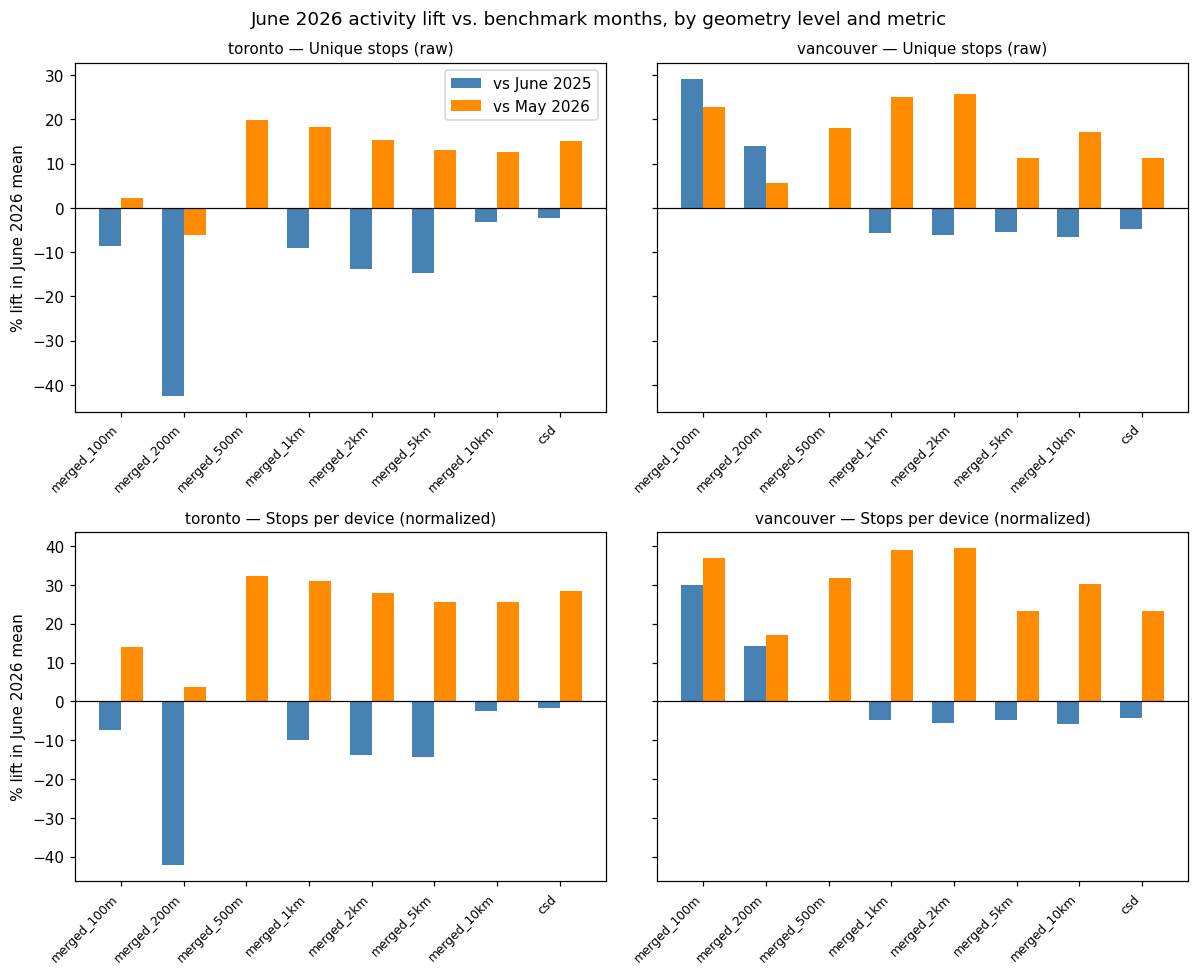

In [5]:
fig, axes = plt.subplots(len(METRICS), len(CITIES), figsize=(11, 4.5 * len(METRICS)), sharey="row")
x = np.arange(len(LEVELS))
width = 0.35

for i, (metric, metric_label) in enumerate(METRICS):
    for j, city in enumerate(CITIES):
        ax = axes[i, j]
        sub = benchmark_summary[(benchmark_summary["metric"] == metric) & (benchmark_summary["city"] == city)] \
            .set_index("level").reindex(LEVELS)
        ax.bar(x - width / 2, sub["june26_vs_june25_pct"], width, label="vs June 2025", color="steelblue")
        ax.bar(x + width / 2, sub["june26_vs_may26_pct"], width, label="vs May 2026", color="darkorange")
        ax.axhline(0, color="black", lw=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels(LEVELS, rotation=45, ha="right", fontsize=8)
        ax.set_title(f"{city} — {metric_label}", fontsize=10)
        if j == 0:
            ax.set_ylabel("% lift in June 2026 mean")

axes[0, 0].legend()
fig.suptitle("June 2026 activity lift vs. benchmark months, by geometry level and metric")
fig.tight_layout()
plt.show()

## 3. Match days vs. non-match days within June 2026

This is the sharpest test: within the *same* month (so no seasonality confound), does a city's own match days stand out from its own non-match days? Note **June 26th is a match day for both cities** (Toronto's 5th group match and Vancouver's 5th group match land on the same date), so it's worth checking whether that day shows an especially large combined bump.

For each city/level/metric we compute three numbers:
- mean value on that city's match days in June 2026
- mean value on that city's non-match days in June 2026
- the match-day lift over non-match days, over May 2026, and over June 2025 — so match days sit alongside the two benchmark months on the same footing, for both the raw count and the normalized rate.

In [6]:
rows = []
for metric, metric_label in METRICS:
    for city in CITIES:
        for level in LEVELS:
            sub = df[(df["city"] == city) & (df["level"] == level)]
            june26 = sub[(sub["DATE"] >= JUNE_2026[0]) & (sub["DATE"] <= JUNE_2026[1])]
            is_match = june26["DATE"].isin(MATCH_DAYS[city])
            match_mean = june26.loc[is_match, metric].mean()
            nonmatch_mean = june26.loc[~is_match, metric].mean()
            june25_mean = window_mean(sub, JUNE_2025, metric)
            may26_mean = window_mean(sub, MAY_2026, metric)
            rows.append({
                "metric": metric,
                "city": city,
                "level": level,
                "match_day_mean": match_mean,
                "non_match_day_mean": nonmatch_mean,
                "match_vs_nonmatch_pct": (match_mean / nonmatch_mean - 1) * 100,
                "match_vs_may26_pct": (match_mean / may26_mean - 1) * 100 if pd.notna(may26_mean) else np.nan,
                "match_vs_june25_pct": (match_mean / june25_mean - 1) * 100 if pd.notna(june25_mean) else np.nan,
            })

match_summary = pd.DataFrame(rows).sort_values(["metric", "city", "level"])
match_summary

,metric,city,level,match_day_mean,non_match_day_mean,match_vs_nonmatch_pct,match_vs_may26_pct,match_vs_june25_pct
7,UNIQUESTOPS,toronto,csd,"320,098","279,202",15,29,9
0,UNIQUESTOPS,toronto,merged_100m,285,278,3,4,-7
6,UNIQUESTOPS,toronto,merged_10km,"173,604","149,640",16,27,9
3,UNIQUESTOPS,toronto,merged_1km,"10,325","8,646",19,37,5
1,UNIQUESTOPS,toronto,merged_200m,"2,563","1,981",29,16,-29
4,UNIQUESTOPS,toronto,merged_2km,"23,221","20,023",16,30,-3
2,UNIQUESTOPS,toronto,merged_500m,"6,645","5,426",22,42,NaN
5,UNIQUESTOPS,toronto,merged_5km,"110,685","95,701",16,27,-4
15,UNIQUESTOPS,vancouver,csd,"71,094","61,663",15,25,7
8,UNIQUESTOPS,vancouver,merged_100m,960,711,35,56,65


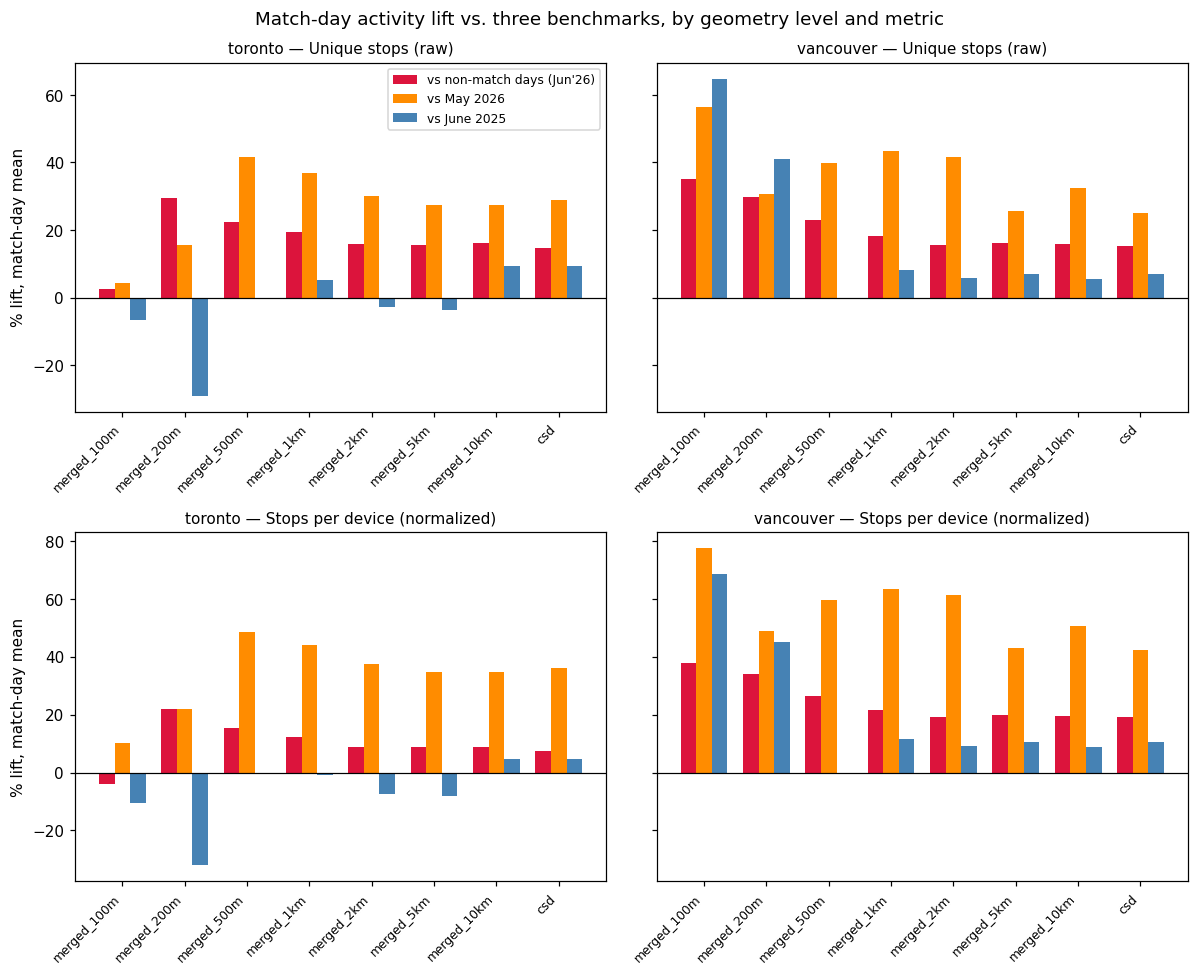

In [7]:
fig, axes = plt.subplots(len(METRICS), len(CITIES), figsize=(11, 4.5 * len(METRICS)), sharey="row")
x = np.arange(len(LEVELS))
width = 0.25

for i, (metric, metric_label) in enumerate(METRICS):
    for j, city in enumerate(CITIES):
        ax = axes[i, j]
        sub = match_summary[(match_summary["metric"] == metric) & (match_summary["city"] == city)] \
            .set_index("level").reindex(LEVELS)
        ax.bar(x - width, sub["match_vs_nonmatch_pct"], width, label="vs non-match days (Jun'26)", color="crimson")
        ax.bar(x, sub["match_vs_may26_pct"], width, label="vs May 2026", color="darkorange")
        ax.bar(x + width, sub["match_vs_june25_pct"], width, label="vs June 2025", color="steelblue")
        ax.axhline(0, color="black", lw=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels(LEVELS, rotation=45, ha="right", fontsize=8)
        ax.set_title(f"{city} — {metric_label}", fontsize=10)
        if j == 0:
            ax.set_ylabel("% lift, match-day mean")

axes[0, 0].legend(fontsize=8)
fig.suptitle("Match-day activity lift vs. three benchmarks, by geometry level and metric")
fig.tight_layout()
plt.show()

## 4. June 2025 vs. May 2026 vs. June 2026, aligned by day-of-month

One panel per city/level (levels as rows, ordered smallest -> largest geometry; cities as columns), with all **three months overlaid on the same x-axis (day-of-month 1–31)** so we can directly compare the shape of June 2026 against both benchmark months at a glance. Each month is a different color; **black diamonds mark that city's FIFA match days in June 2026** so we can see whether the June 2026 line pulls away from the other two exactly on those days. Y-axis is shared within each row (same geometry level, both cities) so the two cities are comparable to each other too.

We run this once for raw `UNIQUESTOPS` and once for `normed_devices` — two separate grids below, since the two metrics live on very different scales.

metric:   0%|          | 0/2 [00:00<?, ?it/s]

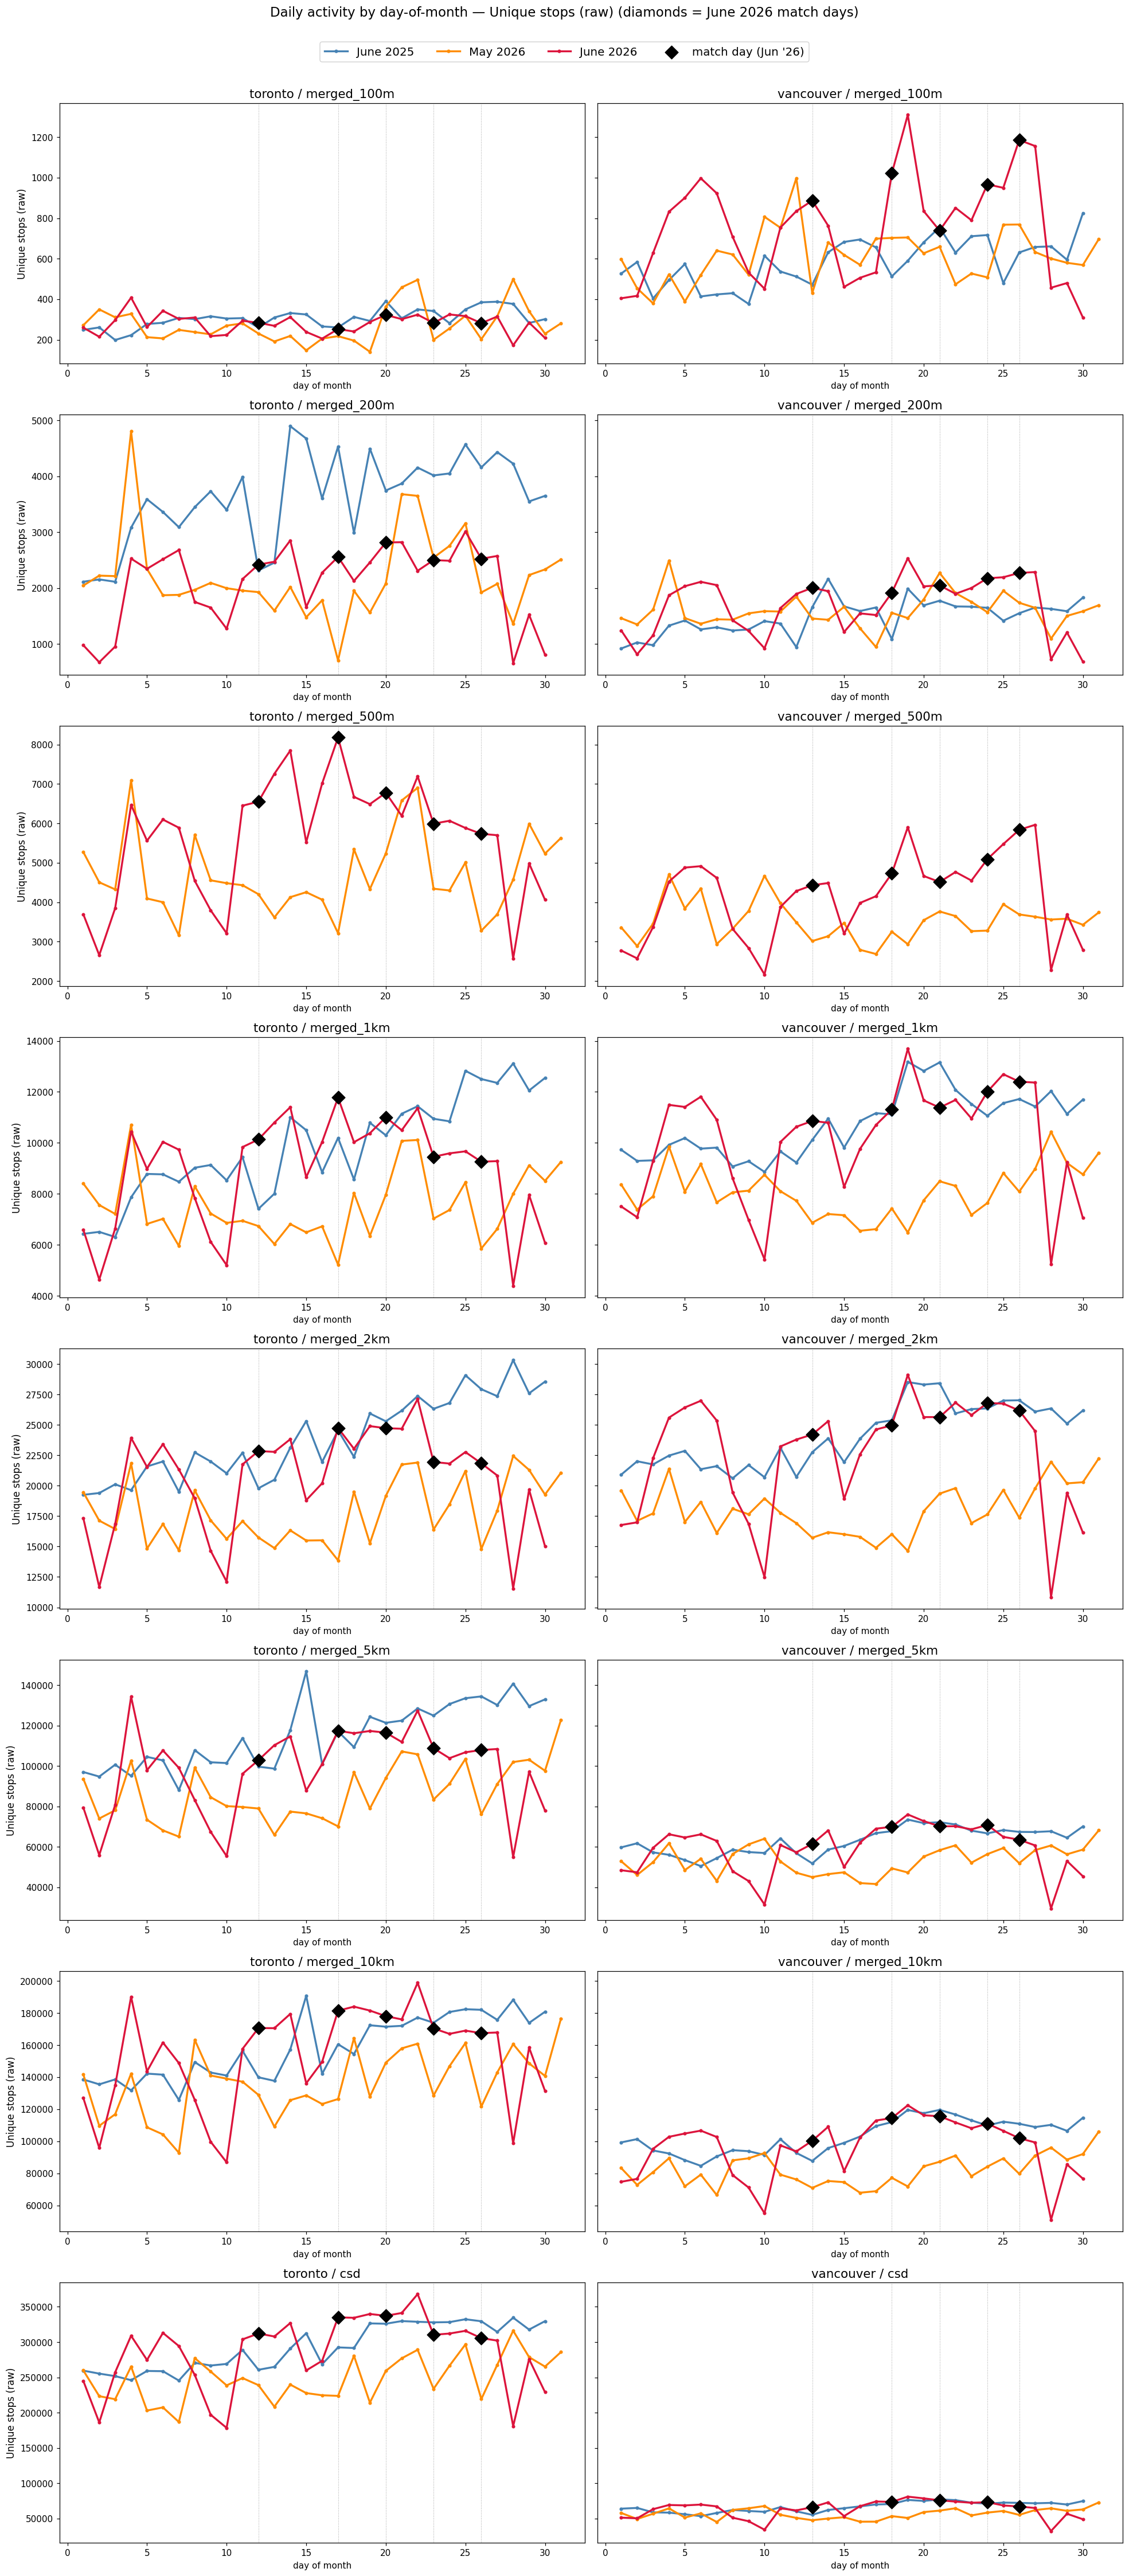

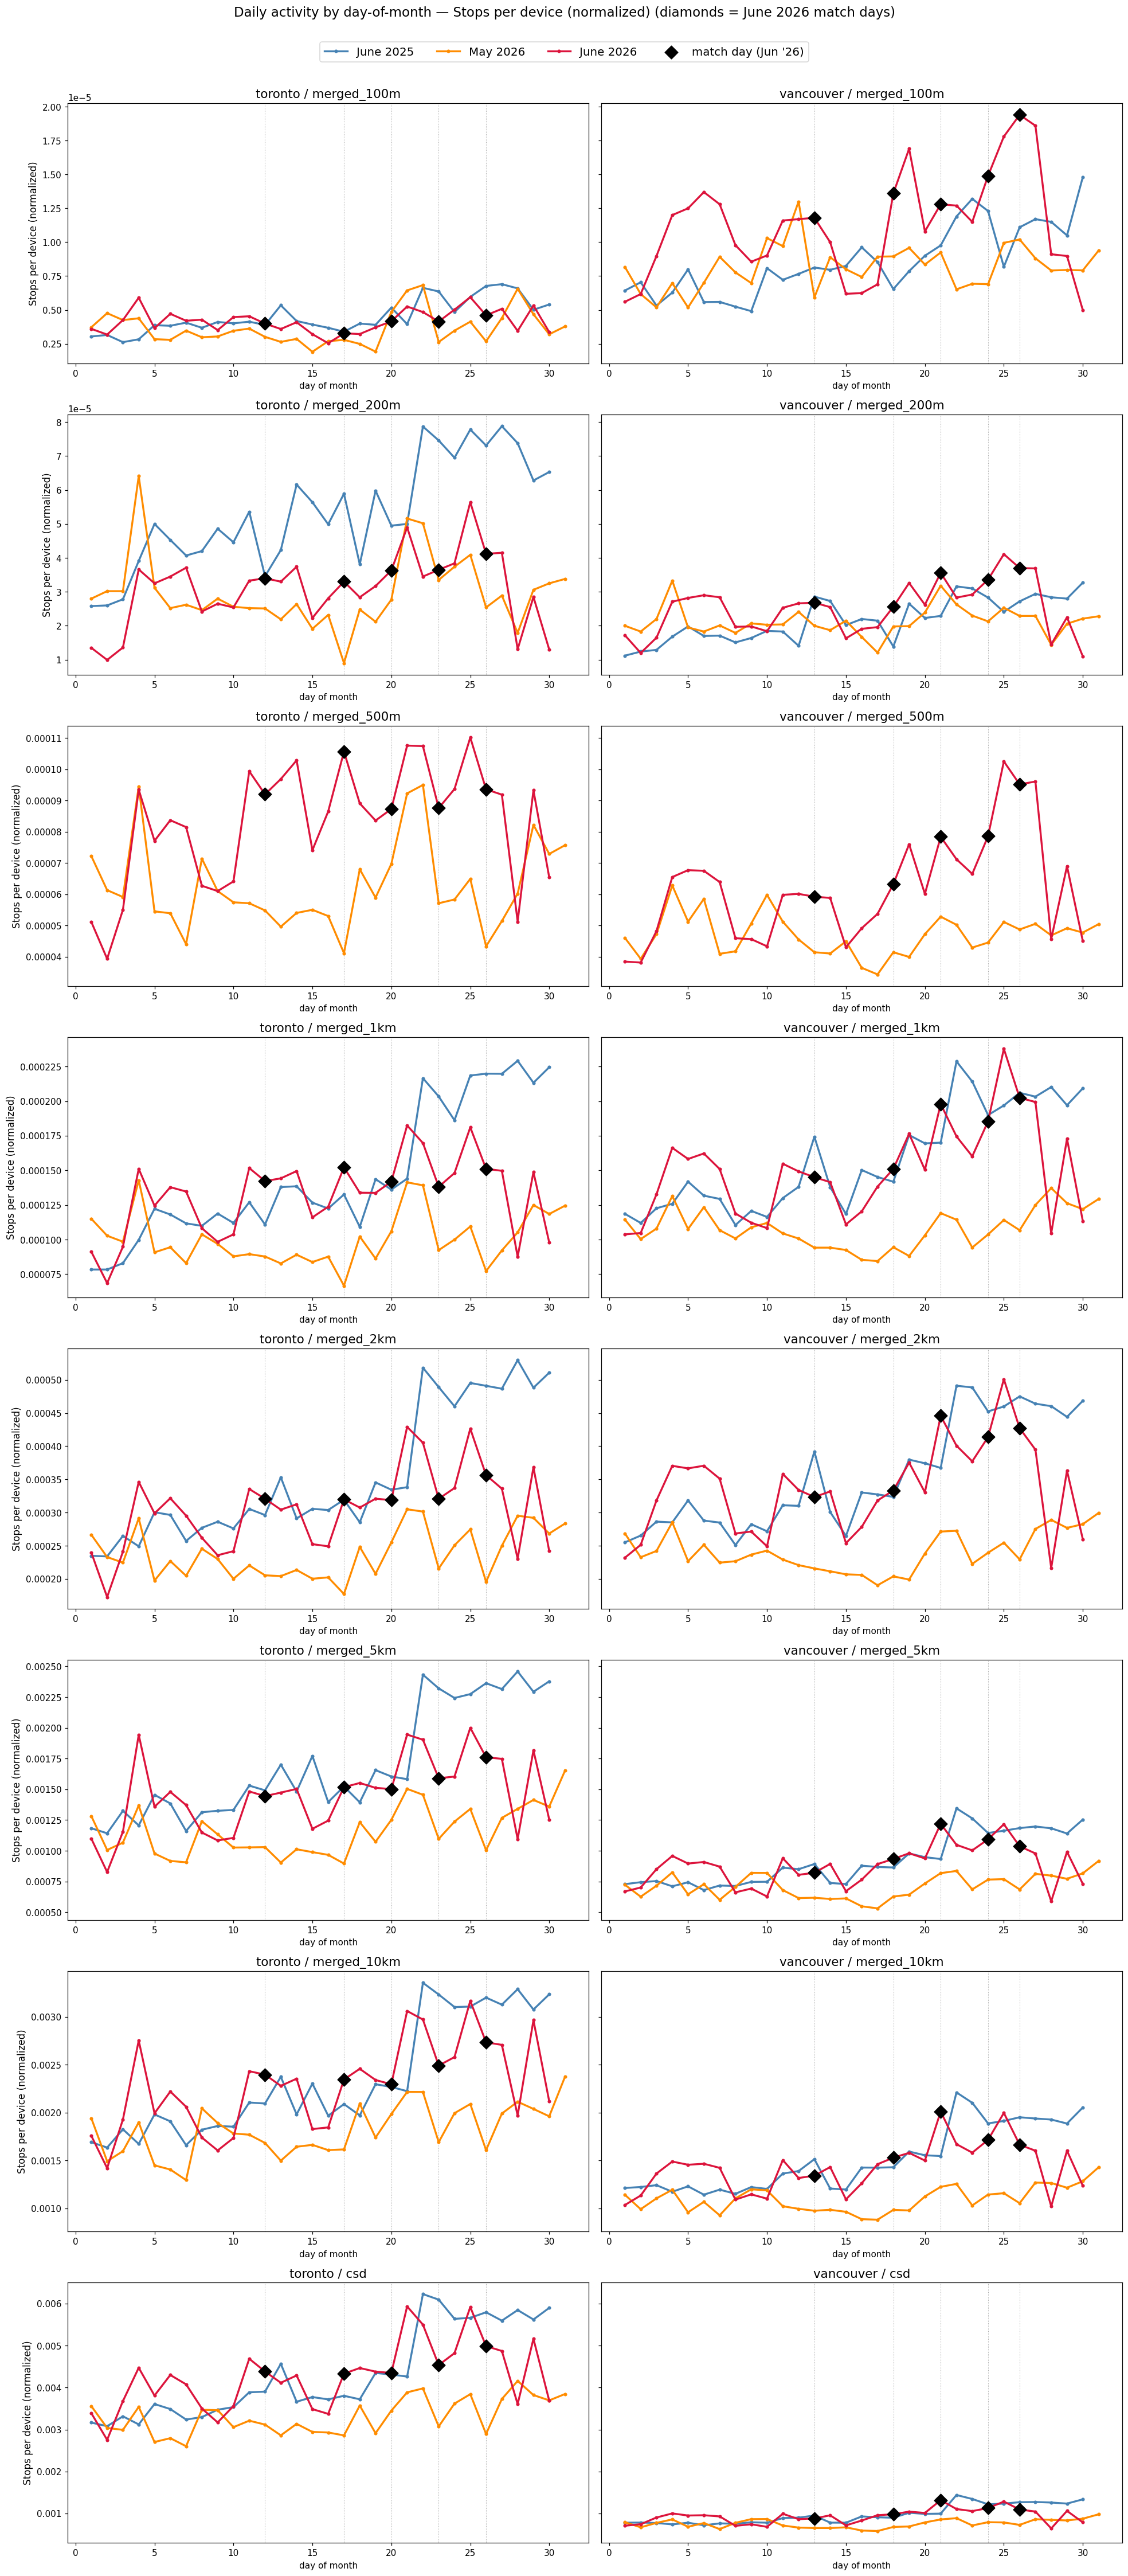

In [8]:
MONTH_WINDOWS = [
    ("June 2025", JUNE_2025, "steelblue"),
    ("May 2026", MAY_2026, "darkorange"),
    ("June 2026", JUNE_2026, "crimson"),
]

def plot_month_overlay(metric, metric_label):
    fig, axes = plt.subplots(len(LEVELS), len(CITIES), figsize=(9 * len(CITIES), 5 * len(LEVELS)), sharey="row")

    for j, city in enumerate(CITIES):
        for i, level in enumerate(LEVELS):
            ax = axes[i, j]
            sub = df[(df["city"] == city) & (df["level"] == level)]

            for label, window, color in MONTH_WINDOWS:
                start, end = pd.to_datetime(window[0]), pd.to_datetime(window[1])
                w = sub[(sub["DATE"] >= start) & (sub["DATE"] <= end)].sort_values("DATE")
                if w.empty:
                    continue
                ax.plot(w["DATE"].dt.day, w[metric], lw=2.2, color=color, label=label, marker="o", markersize=3)

            june26 = sub[(sub["DATE"] >= JUNE_2026[0]) & (sub["DATE"] <= JUNE_2026[1])].sort_values("DATE")
            is_match = june26["DATE"].isin(MATCH_DAYS[city])
            match_days_of_month = june26.loc[is_match, "DATE"].dt.day
            for d in match_days_of_month:
                ax.axvline(d, color="black", lw=0.7, ls=":", alpha=0.35, zorder=0)
            ax.scatter(match_days_of_month, june26.loc[is_match, metric],
                       color="black", zorder=5, s=110, marker="D", label="match day (Jun '26)")

            ax.set_title(f"{city} / {level}", fontsize=14)
            ax.set_xlabel("day of month", fontsize=10)
            ax.tick_params(labelsize=10)
            if j == 0:
                ax.set_ylabel(metric_label, fontsize=11)

    handles, labels_ = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels_, loc="upper center", ncol=4, fontsize=13, bbox_to_anchor=(0.5, 1.008))
    fig.suptitle(f"Daily activity by day-of-month — {metric_label} (diamonds = June 2026 match days)",
                 y=1.02, fontsize=15)
    fig.tight_layout()
    plt.show()

for metric, metric_label in tqdm(METRICS, desc="metric"):
    plot_month_overlay(metric, metric_label)

## 5. Which comparison shows the clearest lift?

Collapse everything into one table: for each metric/city/level, line up all four % lift measures (vs. June 2025, vs. May 2026, match-day vs. non-match-day, match-day vs. June 2025) side by side and sort by the match-day-vs-non-match-day lift, since that's the cleanest same-month test. This is the table to point to when telling the story — the comparison point with consistently the largest, most positive lift across levels **and both metrics** is the strongest evidence for a World-Cup effect (vs. one that only shows up in the raw count, which would suggest a panel-size artifact rather than a real activity change).

In [9]:
combined = benchmark_summary.merge(match_summary, on=["metric", "city", "level"], suffixes=("", "_match"))
lift_cols = ["metric", "city", "level", "june26_vs_june25_pct", "june26_vs_may26_pct",
             "match_vs_nonmatch_pct", "match_vs_may26_pct", "match_vs_june25_pct"]
combined[lift_cols].sort_values(["metric", "match_vs_nonmatch_pct"], ascending=[True, False])

,metric,city,level,june26_vs_june25_pct,june26_vs_may26_pct,match_vs_nonmatch_pct,match_vs_may26_pct,match_vs_june25_pct
9,UNIQUESTOPS,vancouver,merged_100m,29,23,35,56,65
12,UNIQUESTOPS,vancouver,merged_200m,14,6,30,31,41
4,UNIQUESTOPS,toronto,merged_200m,-43,-6,29,16,-29
14,UNIQUESTOPS,vancouver,merged_500m,NaN,18,23,40,NaN
6,UNIQUESTOPS,toronto,merged_500m,NaN,20,22,42,NaN
3,UNIQUESTOPS,toronto,merged_1km,-9,18,19,37,5
11,UNIQUESTOPS,vancouver,merged_1km,-6,25,18,43,8
15,UNIQUESTOPS,vancouver,merged_5km,-5,11,16,26,7
2,UNIQUESTOPS,toronto,merged_10km,-3,13,16,27,9
5,UNIQUESTOPS,toronto,merged_2km,-14,15,16,30,-3


## 6. Takeaways

**The match-day vs. non-match-day comparison is still the cleanest, most consistent signal — and it survives normalizing for device-panel size in almost every case.** Of the 16 city/level combinations, `match_vs_nonmatch_pct` on the raw count is positive every time (+3% to +35%); on `normed_devices` it's positive in 15 of 16, with the single exception being **Toronto's `merged_100m`**, where the raw +3% lift flips to a slight **-4%** once normalized. That's a meaningful caveat: at the immediate-stadium footprint in Toronto specifically, the apparent match-day bump looks like it's driven mostly by more devices being observed that day (a bigger denominator's numerator, not a real behavior change) rather than genuinely elevated foot traffic. Everywhere else — including Toronto's own `csd` level and every Vancouver level — the lift holds up under normalization, and in most Vancouver rows it's actually a bit *larger* after normalizing (e.g. `merged_100m` goes from +35% raw to +38% normalized; `csd` from +15% to +19%).

**The two "benchmark month" comparisons are noisier and sometimes point the wrong way, for both metrics:**
- `june26_vs_june25_pct` is negative for most Toronto levels and several Vancouver levels on both the raw count and the normalized rate — whole-month June 2026 isn't reliably higher than June 2025 either way. Averaging in ~25 non-match days per month dilutes the effect, and/or June 2025 already had its own seasonal baseline.
- `june26_vs_may26_pct` is consistently positive on both metrics but smaller than the match-day-specific lifts.

**Match days pop out most clearly against the May 2026 baseline** (`match_vs_may26_pct`), on both metrics — but this is the weakest comparison to lean on for the story since May 2026 activity already ran a bit below June 2026's own non-match-day baseline, inflating the apparent lift. **For the story, the best comparison point is still match days vs. non-match days within June 2026, evaluated on `normed_devices`** — it isolates the game-day effect, controls for panel-size drift, and is positive across 15 of 16 city/geometry combinations. The one flagged exception (Toronto `merged_100m`) is worth calling out explicitly rather than papering over, since it's a genuine case where the raw-count story and the normalized story disagree.

**Spatial resolution matters, and normalizing sharpens rather than blurs that pattern:** the lift tends to be largest at the finer buffer rings closest to the stadium for Vancouver on both metrics, while Toronto's finest ring (`merged_100m`) is the one geometry where normalizing erases the effect entirely — worth a closer look at what's actually being captured in that specific small footprint (e.g., a venue-adjacent area that's already saturated on both match and non-match days, or a small-sample noise issue, or a real difference in how Toronto's stadium precinct behaves vs. Vancouver's).

**Caveats:**
- `merged_500m` for both cities only has data from May 2026 onward, so it has no `june26_vs_june25` or `match_vs_june25` figures on either metric — don't read the `NaN`s there as "no effect," just missing history.
- `daily_final_v2.csv` ships with exact duplicate rows for every date from May 2026 onward; we drop them with `drop_duplicates()` right after loading (see Section 1) — using the file as-is would silently double-weight May–July 2026 in any mean.